# First brick: `xi0(t)` from the available CSV

In the paper, the exact construction of `xi0(t)` uses the Carr-Madan log-contract formula applied to a full OTM SPX surface, after interpolating each maturity slice.

With the current CSV we only have a few strikes close to spot for each maturity, so this notebook starts with a clean proxy:
- build one ATM implied volatility per maturity,
- convert it into total variance `w(T) = sigma_atm(T)^2 * T`,
- approximate `xi0` by the slope of `w(T)` between maturities,
- represent `xi0(t)` as piecewise constant.

This is a good first implementation block for the project, but it is **not yet** the exact stripping method from the paper.

In [14]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

FRENCH_MONTHS = {
    "janvier": 1,
    "fevrier": 2,
    "février": 2,
    "mars": 3,
    "avril": 4,
    "mai": 5,
    "juin": 6,
    "juillet": 7,
    "aout": 8,
    "août": 8,
    "septembre": 9,
    "octobre": 10,
    "novembre": 11,
    "decembre": 12,
    "décembre": 12,
}

CBOE_COLUMNS = [
    "expiration",
    "call_symbol",
    "call_last",
    "call_net",
    "call_bid",
    "call_ask",
    "call_volume",
    "call_iv",
    "call_delta",
    "call_gamma",
    "call_oi",
    "strike",
    "put_symbol",
    "put_last",
    "put_net",
    "put_bid",
    "put_ask",
    "put_volume",
    "put_iv",
    "put_delta",
    "put_gamma",
    "put_oi",
]

NUMERIC_COLUMNS = [
    column
    for column in CBOE_COLUMNS
    if column not in {"expiration", "call_symbol", "put_symbol"}
]


def parse_spx_metadata(csv_path: str | Path) -> tuple[pd.Timestamp, float]:
    lines = Path(csv_path).read_text(encoding="utf-8").splitlines()

    last_match = re.search(r"Last:\s*([0-9.]+)", lines[1])
    bid_match = re.search(r"Bid:\s*([0-9.]+)", lines[2])
    ask_match = re.search(r"Ask:\s*([0-9.]+)", lines[2])
    if last_match is None:
        raise ValueError("Could not parse the underlying level from the CSV header.")

    date_match = re.search(
        r"Date:\s*(\d{1,2})\s+([A-Za-zéûôîàù]+)\s+(\d{4})",
        lines[2],
    )
    if date_match is None:
        raise ValueError("Could not parse quote date from the CSV header.")

    day = int(date_match.group(1))
    month_name = date_match.group(2).lower()
    year = int(date_match.group(3))

    if month_name not in FRENCH_MONTHS:
        raise ValueError(f"Unknown month name: {month_name}")

    quote_date = pd.Timestamp(
        year=year,
        month=FRENCH_MONTHS[month_name],
        day=day,
    )
    if bid_match is not None and ask_match is not None:
        spot = 0.5 * (float(bid_match.group(1)) + float(ask_match.group(1)))
    else:
        spot = float(last_match.group(1))
    return quote_date, spot


def load_spx_chain(csv_path: str | Path) -> tuple[pd.DataFrame, pd.Timestamp, float]:
    quote_date, spot = parse_spx_metadata(csv_path)

    df = pd.read_csv(csv_path, skiprows=3, names=CBOE_COLUMNS)
    df = df.loc[df["expiration"] != "Expiration Date"].copy()

    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df["expiration"] = pd.to_datetime(df["expiration"], format="%a %b %d %Y")
    df["ttm_years"] = (df["expiration"] - quote_date).dt.days / 365.0

    # Ignore same-day expiry for this first simple implementation.
    df = df.loc[df["ttm_years"] > 0.0].copy()
    return df, quote_date, spot


def extract_atm_term_structure(df: pd.DataFrame, spot: float) -> pd.DataFrame:
    atm = (
        df.assign(distance_to_spot=(df["strike"] - spot).abs())
        .sort_values(["expiration", "distance_to_spot", "strike"])
        .groupby("expiration", as_index=False)
        .first()
    )

    atm["atm_iv"] = 0.5 * (atm["call_iv"] + atm["put_iv"])
    atm["total_variance"] = atm["atm_iv"] ** 2 * atm["ttm_years"]

    return atm[
        [
            "expiration",
            "ttm_years",
            "strike",
            "call_iv",
            "put_iv",
            "atm_iv",
            "total_variance",
        ]
    ].sort_values("ttm_years").reset_index(drop=True)


def build_piecewise_constant_xi0(atm_curve: pd.DataFrame):
    curve = atm_curve[["expiration", "ttm_years", "total_variance"]].copy()
    curve["t_left"] = curve["ttm_years"].shift(1)
    curve["w_left"] = curve["total_variance"].shift(1)
    curve = curve.dropna().copy()

    curve["xi0"] = (
        (curve["total_variance"] - curve["w_left"])
        / (curve["ttm_years"] - curve["t_left"])
    ).clip(lower=0.0)

    xi0_table = curve[
        ["t_left", "ttm_years", "expiration", "xi0"]
    ].rename(columns={"ttm_years": "t_right"}).reset_index(drop=True)

    t_left = xi0_table["t_left"].to_numpy()
    t_right = xi0_table["t_right"].to_numpy()
    xi0_values = xi0_table["xi0"].to_numpy()

    def xi0(t):
        t = np.asarray(t, dtype=float)
        idx = np.searchsorted(t_right, t, side="right")
        idx = np.clip(idx, 0, len(xi0_values) - 1)

        values = xi0_values[idx]
        values = np.where(t < t_left[0], xi0_values[0], values)
        return values if values.ndim > 0 else float(values)

    return xi0_table, xi0


def build_smooth_xi0(xi0_table: pd.DataFrame):
    midpoints = 0.5 * (xi0_table["t_left"].to_numpy() + xi0_table["t_right"].to_numpy())
    xi0_values = xi0_table["xi0"].to_numpy()

    knot_t = np.concatenate((
        [xi0_table["t_left"].iloc[0]],
        midpoints,
        [xi0_table["t_right"].iloc[-1]],
    ))
    knot_xi0 = np.concatenate((
        [xi0_values[0]],
        xi0_values,
        [xi0_values[-1]],
    ))

    interpolator = PchipInterpolator(knot_t, knot_xi0, extrapolate=True)
    t_min = float(knot_t[0])
    t_max = float(knot_t[-1])
    left_value = float(knot_xi0[0])
    right_value = float(knot_xi0[-1])

    def smooth_xi0(t):
        t = np.asarray(t, dtype=float)
        values = interpolator(t)
        values = np.clip(values, 0.0, None)
        values = np.where(t < t_min, left_value, values)
        values = np.where(t > t_max, right_value, values)
        return values if values.ndim > 0 else float(values)

    return smooth_xi0


In [15]:
chain, quote_date, spot = load_spx_chain("spx_quotedata.csv")
atm_curve = extract_atm_term_structure(chain, spot)
xi0_table, xi0 = build_piecewise_constant_xi0(atm_curve)
smooth_xi0 = build_smooth_xi0(xi0_table)

print(f"quote_date = {quote_date.date()}")
print(f"spot = {spot:.2f}")

atm_curve

quote_date = 2026-04-10
spot = 6827.43


,expiration,ttm_years,strike,call_iv,put_iv,atm_iv,total_variance
0,2026-04-13,0.008219,6825.0,0.1156,0.1150,0.11530,0.000109
1,2026-04-14,0.010959,6825.0,0.1248,0.1250,0.12490,0.000171
2,2026-04-15,0.013699,6825.0,0.1324,0.1321,0.13225,0.000240
3,2026-04-16,0.016438,6825.0,0.1375,0.1372,0.13735,0.000310
4,2026-04-17,0.019178,6825.0,0.1389,0.1388,0.13885,0.000370
5,2026-04-20,0.027397,6825.0,0.1372,0.1371,0.13715,0.000515
6,2026-04-21,0.030137,6825.0,0.1405,0.1403,0.14040,0.000594
7,2026-04-22,0.032877,6825.0,0.1439,0.1438,0.14385,0.000680
8,2026-04-23,0.035616,6825.0,0.1464,0.1462,0.14630,0.000762
9,2026-04-24,0.038356,6825.0,0.1493,0.1492,0.14925,0.000854


In [16]:
xi0_table

,t_left,t_right,expiration,xi0
0,0.008219,0.010959,2026-04-14,0.022518
1,0.010959,0.013699,2026-04-15,0.025050
2,0.013699,0.016438,2026-04-16,0.025740
3,0.016438,0.019178,2026-04-17,0.021765
4,0.019178,0.027397,2026-04-20,0.017715
5,0.027397,0.030137,2026-04-21,0.028733
6,0.030137,0.032877,2026-04-22,0.031480
7,0.032877,0.035616,2026-04-23,0.029934
8,0.035616,0.038356,2026-04-24,0.033610
9,0.038356,0.046575,2026-04-27,0.015518


In [17]:
sample_grid = np.array([7, 10, 14, 20, 30]) / 365.0
pd.DataFrame({
    "t_years": sample_grid,
    "xi0_step(t)": xi0(sample_grid),
    "xi0_smooth(t)": smooth_xi0(sample_grid),
})

,t_years,xi0_step(t),xi0_smooth(t)
0,0.019178,0.017715,0.020349
1,0.027397,0.028733,0.026017
2,0.038356,0.015518,0.030783
3,0.054795,0.048693,0.048693
4,0.082192,0.048693,0.048693


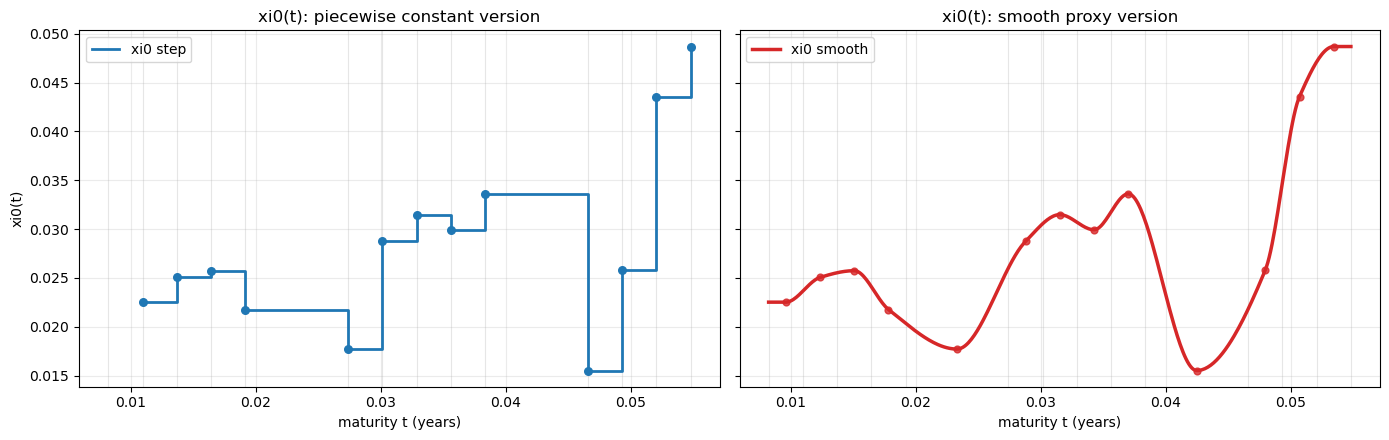

number of maturities used: 14
number of xi0 intervals: 13
The smooth curve is only a visual/interpolation proxy built from the stepwise xi0.


In [18]:
t_dense = np.linspace(xi0_table["t_left"].iloc[0], xi0_table["t_right"].iloc[-1], 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

axes[0].step(
    xi0_table["t_right"],
    xi0_table["xi0"],
    where="post",
    linewidth=2,
    color="#1f77b4",
    label="xi0 step",
)
axes[0].scatter(
    xi0_table["t_right"],
    xi0_table["xi0"],
    s=30,
    color="#1f77b4",
    zorder=3,
)

axes[1].plot(
    t_dense,
    smooth_xi0(t_dense),
    linewidth=2.5,
    color="#d62728",
    label="xi0 smooth",
)
axes[1].scatter(
    0.5 * (xi0_table["t_left"] + xi0_table["t_right"]),
    xi0_table["xi0"],
    s=24,
    color="#d62728",
    alpha=0.8,
    zorder=3,
)

for ax in axes:
    for t in atm_curve["ttm_years"]:
        ax.axvline(t, color="0.9", linewidth=0.8, zorder=0)
    ax.set_xlabel("maturity t (years)")
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_title("xi0(t): piecewise constant version")
axes[1].set_title("xi0(t): smooth proxy version")
axes[0].set_ylabel("xi0(t)")

plt.tight_layout()
plt.show()

print(f"number of maturities used: {len(atm_curve)}")
print(f"number of xi0 intervals: {len(xi0_table)}")
print("The smooth curve is only a visual/interpolation proxy built from the stepwise xi0.")
